## <span style="color:blue"> Lezione 7 </span>



In [1]:

import matplotlib.pyplot as plt
import numpy as np

parent_folder="l_07_all_es/RESULTS/"


È dato un sistema di $108$ particelle, con condizioni periodiche al contorno e soggetto al potenziale di Lennard-Jones che rappesenta un liquido 
con temperatura $T^*=1.1$ e densità $\rho=0.8$.

Si vogliono stimare le seguenti quantità: 
- energia potenziale per particella.
- pressione
- funzione di distribuzione radiale  $g(r)$

tramite due tipi di simulazione
- dinamica molecolare (MD) con l'algoritmo di Verlet 
- Monte Carlo (MC) con l'algoritmo di Metropolis (ensamble canonico). 

In questo caso, l'algoritmo di Metropolis utilizza la seguente proposta di mossa: 

1. Si sceglie casualmente una particella.
2. Si crea un vettore $\vec{x}$ di $N_{\mathrm{dim}}$ (numero di dimensioni) numeri casuali nell'intervallo $[-\delta,\delta)$ con probabilità uniforme. $\delta$ è un parametro fornito al sistema.
3. Si trasla la particella di $\vec{x}$. 

La mossa viene accettata con probabilità $$A=\min \left[1, \frac{\exp(-\beta V(\vec{r}_1,...,\vec{r}_i + \vec{x},...,\vec{r}_{N}))}{\exp(-\beta V(\vec{r}_1,...,\vec{r}_i,...,\vec{r}_{N}))}\right],$$
con $V$ potenziale del sistema (la mossa non agisce sulla parte cinetica).

### <span style="color:DodgerBlue"> Esercizio 7.2 </span>



I parametri delle simulazioni sono: $N_{\mathrm{part}}=108$ particelle, densità $\rho=0.8$ raggio di cut-off $R_{\mathrm{cut}}=2.5$ e temperatura $T^*=1.1$. 
Per l'algoritmo di Verlet si è scelto come passo $\delta t=0.001$, mentre per l'algoritmo di Metropolis $\delta=0.1$ (a cui corrisponde un'accettanza del 50% circa). 

Prima di effettuare le simulazioni, è necessario valutare due fenomeni. Innanzitutto, le simulazioni, sia dinamica molecolare (MD) con l'algoritmo di Verlet, sia Monte Carlo (MC) con l'algoritmo di Metropolis, intercorrono una fase di equilibrazione. Per valutarla, sono state eseguite le simulazioni con $10000$ blocchi e $1$ passo per blocco, e si sono stampati i dati di energia potenziale e temperatura (solo per MD), che vengono caricati nella cella sottostante. 

In [2]:
n_MD,MD_pot_en=np.loadtxt(parent_folder + "10000_blk_1_steps_0_eqsteps/OUTPUT_MD/potential_energy.dat",usecols=(0,1),unpack=True)
n_MC,MC_pot_en=np.loadtxt(parent_folder + "10000_blk_1_steps_0_eqsteps/OUTPUT_MC/potential_energy.dat",usecols=(0,1),unpack=True)
temp=np.loadtxt(parent_folder + "10000_blk_1_steps_0_eqsteps/OUTPUT_MD/temperature.dat",usecols=1)


Nella cella sottostante, invece, è riportato il codice che genera due grafici: il primo mette a confronto l'energia potenziale del blocco (e quindi istantanea) per MC e MD in funzione del numero di blocchi (e quindi di step), il secondo mostra invece la temperatura, sempre istantanea, di MD in funzione del numero di blocchi. Siccome nella fase di equilibrazione di MD la temperatura si abbassa, per effettuare una simulazione ad una temperatura di $1.1$ bisogna partire da una temperatura più alta ( $2.0$). 

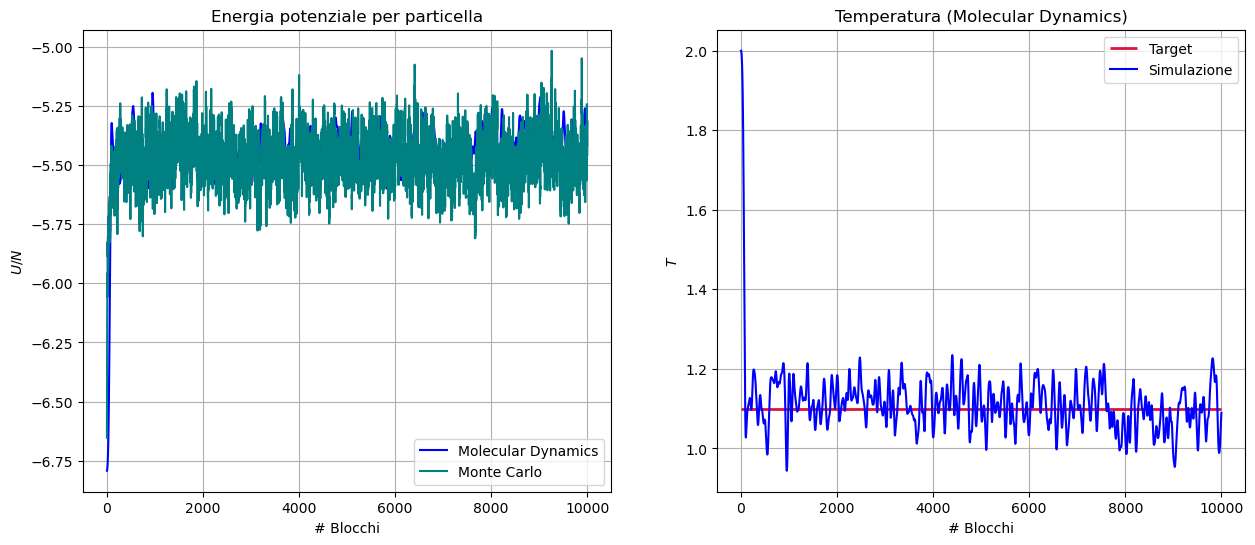

In [3]:

fig,axs=plt.subplots(1,2,figsize=[15,6])

axs[0].errorbar(n_MD,MD_pot_en,label="Molecular Dynamics",color="blue")
axs[0].errorbar(n_MC,MC_pot_en,label="Monte Carlo",color="teal")
axs[0].legend()
axs[0].set_title("Energia potenziale per particella")
axs[0].grid()
axs[0].set_xlabel("# Blocchi")
axs[0].set_ylabel(r"$U/N$")



axs[1].errorbar(n_MD,temp,color="blue", label="Simulazione")
axs[1].hlines(1.1,0,n_MD.max(),label="Target",color="crimson",linewidth=2)
axs[1].legend()
axs[1].grid()
axs[1].set_title("Temperatura (Molecular Dynamics)")
axs[1].set_xlabel("# Blocchi")
axs[1].set_ylabel(r"$T$");





Le quantità in esame si trovano molto rapidamente ad oscillare attorno al valor medio. E' evidente,quindi, che, aggiungendo nel main 2000 step di evoluzione "a vuoto" (senza effettuare alcuna misura) il requisito per l'equilibrazione è comodamente soddisfatto. 

Il secondo fenomeno da valutare è la correlazione tra configurazioni contigue, sia per MD che per MC. Ciò viene fatto eseguendo una simulazione per ciascun tipo, con $500000$ blocchi, $1$ step per blocco e $2000$ step di equilibrazione. I dati dell'energia potenziale del blocco delle simulazioni MD e MC vengono caricati nella cella sottostante. 

In [4]:
M=500000
MD_pot_en_=np.loadtxt(parent_folder + "500000_blk_1_steps_2000_eqsteps/OUTPUT_MD/potential_energy.dat",usecols=1)
MC_pot_en_=np.loadtxt(parent_folder + "500000_blk_1_steps_2000_eqsteps/OUTPUT_MC/potential_energy.dat",usecols=1)

### Es 7.2.1



L'autocorrelazione _time displaced_ di una variabile $X$ indica quanto la variabile sia correlata con sè stessa traslata di un intervallo di tempo $t$ e si calcola come: $$ AC_X(t)= \frac{\langle X(t')X(t'+t)\rangle _{t'} - \langle X(t')\rangle _{t'}^2}{\sigma_X^2}$$


Se ora si considera una variabile $X$ misurata per $M$ step discreti di lunghezza uniforme, l'autocorrelazione al passo (o tempo) $m$ è per $M \gg m$ : $$
\mathrm{AC}_{X}(m)=\frac{\frac{1}{M-m} \sum_{i=0}^{M-m}  X(i) X(i+m)  - 
\frac{1}{(M-m)^2} \left( \sum_{i=0}^{M-m}  X(i)\right) \left( \sum_{i=0}^{M-m} X(i+m)\right) } 
 {\frac{1}{M}\sum_{i=0}^M X(i)^2 - \left(\frac{1}{M} \sum_{i=0}^M X(i) \right)^2}$$



La funzione è implementata nella cella sottostante. 

In [5]:
def autocorr_num(x,m,M): #calcola il numeratore dell'autocorrelazione al blocco m
    x_start=x[:M-m]
    x_end=x[m:]
    norm=1/(M-m)
    sum1=0
    sum1 = np.dot(x_start,x_end)
    sum2=x_start.sum()
    sum3=x_end.sum()


    return norm*(sum1 -norm*sum2*sum3)


def calc_autocorr(x,m_val,M): 
    den=x.var() # per tutti gli m il denominatore è la varianza dei dati
    corr=np.zeros(m_val.shape)
    for i,m in enumerate(m_val): 
        corr[i]=autocorr_num(x,int(m),M)


    return corr/den







La cella sottostante calcola l'autocorrelazione per un numero di passi $m$ compreso tra $1$ e $5000$. La cella ancora dopo crea i grafici dell'autocorrelazione in funzione del numero di passi per MC e MD. 

In [6]:

m_val=np.arange(1,5001)
MD_autocorr=calc_autocorr(MD_pot_en_,m_val,M)
MC_autocorr=calc_autocorr(MC_pot_en_,m_val,M)


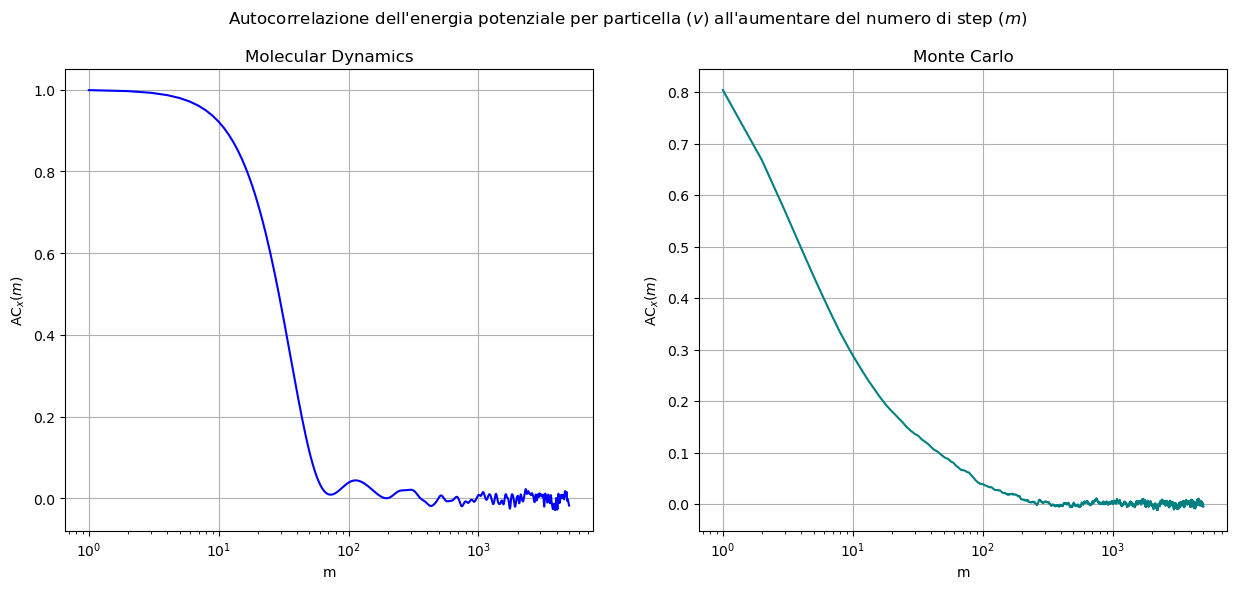

In [7]:
fig,axs=plt.subplots(1,2,figsize=[15,6])


axs[0].plot(m_val,MD_autocorr, color="blue")




axs[0].set_xlabel("m")
axs[0].set_ylabel(r"$\mathrm{AC}_{x}(m)$")
axs[0].grid()
axs[0].semilogx()
axs[0].set_title("Molecular Dynamics")
axs[1].plot(m_val,MC_autocorr,color="teal")
axs[1].set_xlabel("m")
axs[1].set_ylabel(r"$\mathrm{AC}_{x}(m)$")
axs[1].grid()
axs[1].semilogx()
axs[1].set_title("Monte Carlo")
fig.suptitle(r"Autocorrelazione dell'energia potenziale per particella ($v$) all'aumentare del numero di step ($m$)");







### Es 7.2.2


L'obiettivo è studiare l'impatto del data blocking sul calcolo dell'incertezza. Per farlo, si suddividono i $500000$ dati in blocchi di lunghezza $L$ crescente nell'intervallo $[10,5000]$ e, per ciascuna lunghezza $L$, si calcola l'incertezza statistica sulla media dei dati col metodo del data blocking. 

La cella sottostante implementa il calcolo dell'incertezza dell'energia potenziale per ogni lunghezza $L$. 

In [8]:


L_list=np.arange(10,5000,1)
N_list = M // L_list
MD_error=np.zeros(len(L_list))
MC_error=np.zeros(len(L_list))


for i,(N,L) in enumerate(zip(N_list,L_list)):

    reshaped_data = MD_pot_en_[:N*L].reshape((N,L))#riorganizzati i dati in N righe e L colonne (se il divisore non è esatto, elimina qualche dato dalla coda)
    blk_mean=np.mean(reshaped_data,axis=1) #trova la media ogni riga (media del blocco)
    err=np.sqrt(((np.dot(blk_mean,blk_mean))/N- blk_mean.mean()**2)/N)
    MD_error[i]=err

    reshaped_data = MC_pot_en_[:N*L].reshape((N,L))#riorganizzati i dati in N righe e L colonne (se il divisore non è esatto, elimina qualche dato dalla coda)
    blk_mean=np.mean(reshaped_data,axis=1) #trova la media ogni riga (media del blocco)
    err=np.sqrt(((np.dot(blk_mean,blk_mean))/N- blk_mean.mean()**2)/N)
    MC_error[i]=err


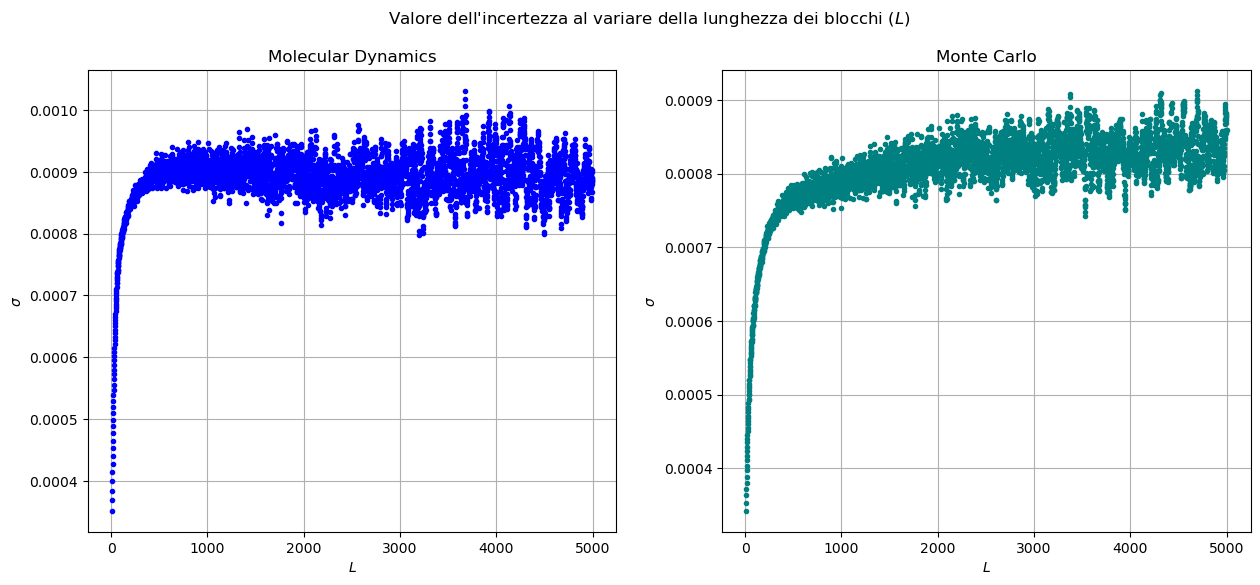

In [9]:
fig,axs=plt.subplots(1,2,figsize=[15,6])


axs[0].plot(L_list,MD_error,".",color="blue")
axs[0].set_xlabel(r"$L$")
axs[0].set_ylabel(r"$\sigma$")
axs[0].grid()
#axs[0].semilogx()
axs[0].set_title("Molecular Dynamics")
axs[1].plot(L_list,MC_error,".",color="teal")
axs[1].set_xlabel(r"$L$")
axs[1].set_ylabel(r"$\sigma$")
axs[1].grid()
#axs[1].semilogx()
axs[1].set_title("Monte Carlo")
fig.suptitle(r"Valore dell'incertezza al variare della lunghezza dei blocchi ($L$) ");



L'incertezza cresce all'aumentare della grandezza $L$ dei blocchi utilizzati per calcolarla. Da un certo valore di $L$ in poi si assesta attorno ad un certo valore costante. Si nota che il valore di $L$ necessario perchè ciò avvenga è comparabile col valore di $m$ dal quale la correlazione può essere considerata trascurabile. Ciò non è una sorpresa: è infatti lo scopo stesso del data blocking "gestire" l'autocorrelazione tramite l'utilizzo di quantità scorrelate tra loro per il calcolo delle incertezze, di modo da poter usare il teorema del limite centrale. D'ora in avanti, dunque, si prenderanno blocchi da $L=1000$ step ciascuno.

### <span style="color:DodgerBlue"> Esercizio 7.3/7.4 </span>



Si effettueranno dunque due simulazioni, MD e MC, con $2000$ step di equilibrazione, $30$ blocchi e $1000$ step per blocco. Di sotto vengono caricati i dati e mostrati i grafici delle quantità di interesse.

In [10]:
n,MD_pot_en,MD_pot_en_err=np.loadtxt(parent_folder + "30_blk_1000_steps_2000_eqsteps/OUTPUT_MD/potential_energy.dat",usecols=(0,2,3),unpack=True)
MC_pot_en,MC_pot_en_err=np.loadtxt(parent_folder + "30_blk_1000_steps_2000_eqsteps/OUTPUT_MC/potential_energy.dat",usecols=(2,3),unpack=True)
MD_pressure,MD_pressure_err=np.loadtxt(parent_folder + "30_blk_1000_steps_2000_eqsteps/OUTPUT_MD/pressure.dat",usecols=(2,3),unpack=True)
MC_pressure,MC_pressure_err=np.loadtxt(parent_folder + "30_blk_1000_steps_2000_eqsteps/OUTPUT_MC/pressure.dat",usecols=(2,3),unpack=True)
bins,MD_gofr,MD_gofr_err=np.loadtxt(parent_folder + "30_blk_1000_steps_2000_eqsteps/OUTPUT_MD/gofr.dat",usecols=(0,1,2),unpack=True)
MC_gofr,MC_gofr_err=np.loadtxt(parent_folder + "30_blk_1000_steps_2000_eqsteps/OUTPUT_MC/gofr.dat",usecols=(1,2),unpack=True)


bin_size=bins[1]
bins+=bin_size/2


###  $g(r)$

Sia dato un sistema a $N$ particelle con una distribuzione di probabilità congiunta $p(\vec{r}_1,...\vec{r}_N)$.
Si definisce  densità a $n$ particelle:  $$ \rho_N^{(n)}(\vec{r}_1,...,\vec{r}_n)= \frac{N!}{(N-n)!}\int \mathrm{d} \vec{r}_{n+1}... \mathrm{d} \vec{r}_{N} p(\vec{r}_1,...,\vec{r}_N)$$ e
distribuzione a $n$ particelle: $$ g_N^{(n)}(\vec{r}_1,...,\vec{r}_n)= \frac{\rho_N^{(n)}(\vec{r}_1,...,\vec{r}_n)}{\prod_{i=1}^{n} \rho_N^{(1)}(\vec{r}_i)}.$$

La funzione di distribuzione radiale $g(r)$ è la distribuzione a due particelle per un sistema omogeneo (per il quale $\rho_N^{(1)}(\vec{r})$ è una costante $\rho=N/V$): $$ g_N^{(2)}(\vec{r}_1,\vec{r}_2)=g_N^{(2)}(|\vec{r}_1-\vec{r}_2|)=g(r) .$$



Operativamente, computare $g(r)$ significa costruire un istogramma con bins di grandezza $\mathrm{d}r$. Si indicherà con $r$ il bordo sinistro del bin. 

Ciclando sulle coppie di particelle, si calcola la loro distanza $d$ e, trovato il bin per cui $r \le d < r+ dr$, ne si aumenta il conteggio di 2. 
Al termine, si normalizza dividendo per $\rho N \Delta V$, con $\Delta V= 4/3 \pi ((r + \mathrm{d}r)^3 - r^3)$. 

Per la simulazione è stato scelto un numero di bins pari a $100$ . Nella cella sottostante sono graficati i risultati (l'istogramma è costituito dai valori medi cumulativi all'ultimo blocco, con relativo errore).

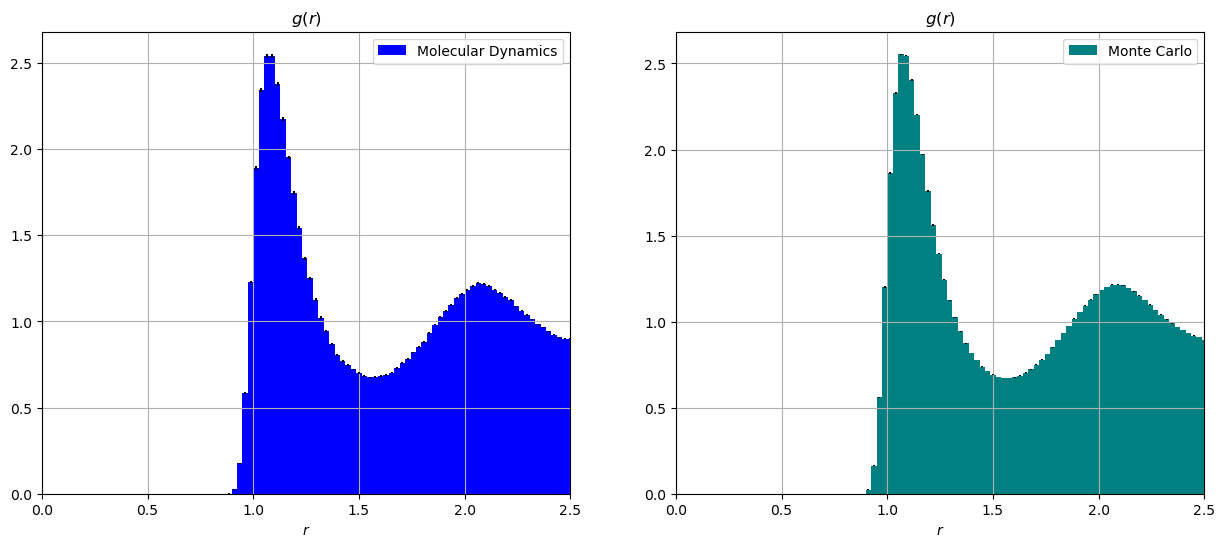

In [11]:


fig,axs=plt.subplots(1,2,figsize=[15,6])

axs[0].bar(bins,MD_gofr,yerr=MD_gofr_err,label="Molecular Dynamics",color="blue",width=bin_size)

axs[0].legend()
axs[0].set_title(r"$g(r)$")
axs[0].grid()
axs[0].set_xlabel(r"$r$")
axs[0].set_xlim([0,2.5])

axs[1].bar(bins,MC_gofr,yerr=MC_gofr_err,label="Monte Carlo",color="teal",width=bin_size)

axs[1].legend()
axs[1].set_title(r"$g(r)$")
axs[1].grid()
axs[1].set_xlabel(r"$r$")
axs[1].set_xlim([0,2.5]);







Per valori della distanza $r$ inferiori a circa $0.8$, $g(r) \sim 0$: ciò è coerente con un potenziale repulsivo a breve distanza, come quello di Lennard Jones. $g(r)$ ha un massimo in corrispondenza di $r=1.1$ circa, dove il potenziale ha il minimo globale, ed un secondo massimo a circa $r=2.2$, in corrispondenza di un minimo locale. Non ci sono dati oltre $r=2.5=r_{\mathrm{cut}}$ per via del cut off. 

La funzione $g(r)$ può essere utile anche per calcolare il valore atteso di una qualsiasi funzione che dipende solo dalla distanza relativa tra coppie di particelle. 

Si consideri ad esempio l'energia potenziale $V(\vec{r}_1,...,\vec{r}_N)= \frac{1}{2} \sum_{i=1}^N \sum_{j \neq i} v(|\vec{r}_i -\vec{r}_j)$. Per un fluido omogeneo, 

$$\langle V \rangle= \int \mathrm{d}\vec{r}_1...\mathrm{d}\vec{r}_N \ V (\vec{r}_1,...,\vec{r}_N) \frac{\exp(-\beta V(\vec{r}_1,...,\vec{r}_N))}{Z} = 
 2 \pi \rho N \int_0^{+\infty} \mathrm{d} r \ r^2 v(r) g(r)  .$$
Ciò permette di correggere almeno in parte l'errore introdotto dall'approsimazione di cut-off. Si stima: $$\langle V_{\mathrm{tail}} \rangle = 2 \pi \rho N \int_{r_{\mathrm{cut}}}^{+\infty} \mathrm{d} r \ r^2 v(r) g(r) \simeq   2 \pi \rho N \int_{r_{\mathrm{cut}}}^{+\infty} \mathrm{d} r \ r^2 v(r) $$

approssimando per $r>r_{\mathrm{cut}}$, $\rho_N^{(2)}(\vec{r}_1,\vec{r}_2) \simeq \rho_N^{(1)}(\vec{r}_1)\rho_N^{(1)}(\vec{r}_2)$, per cui $g(r) \simeq 1$. 




### Energia potenziale

Per un potenziale di Lennard Jones , eseguendo analiticamente il calcolo, si ottiene: $$ \frac{\langle V_{\mathrm{tail}} \rangle }{N }\simeq \frac{8\pi \rho \epsilon}{3}\left(\frac{1}{3 \ r_{\mathrm{cut},lJ}^9} - \frac{1}{ r_{\mathrm{cut},LJ}^3}\right)$$

dove $r_{\mathrm{cut},lJ}$ è $r_{\mathrm{cut}}$ espresso in unità di $\sigma$ del potenziale di Lennard Jones.

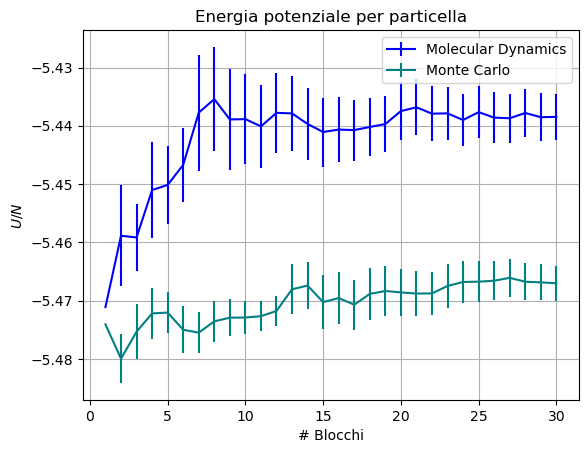

In [12]:
fig,ax=plt.subplots(1,1)

ax.errorbar(n,MD_pot_en,MD_pot_en_err,label="Molecular Dynamics",color="blue")
ax.errorbar(n,MC_pot_en,MC_pot_en_err,label="Monte Carlo",color="teal")
ax.legend()
ax.set_title("Energia potenziale per particella")
ax.grid()
ax.set_xlabel("# Blocchi")
ax.set_ylabel(r"$U/N$");







### Pressione

La pressione può essere calcolata tramite il valore medio del viriale $W=-r \frac{\mathrm{d}U}{\mathrm{d}{R}}$: $$P= \rho k_B T + \frac{\langle W \rangle}{3V}. $$

Le correzioni di coda si ottengono con un calcolo analogo al precedente: $$ \frac{\langle W_{\mathrm{tail}} \rangle }{3 N \epsilon }\simeq \frac{32 \pi \rho }{3}\left(\frac{1}{3 \ r_{\mathrm{cut},LJ}^9} - \frac{1}{ 2 r_{\mathrm{cut},LJ}^3}\right).$$




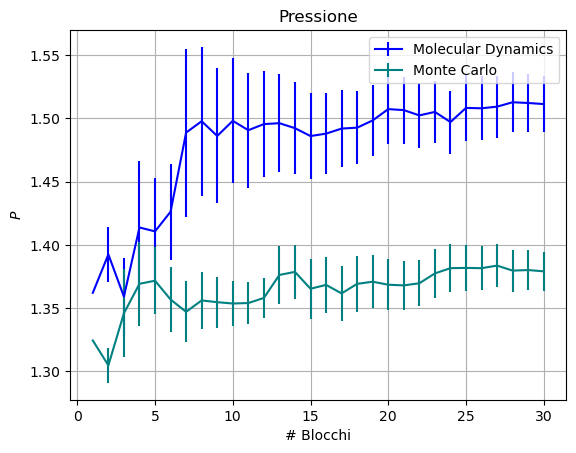

In [13]:
fig,ax=plt.subplots(1,1)

ax.errorbar(n,MD_pressure,MD_pressure_err,label="Molecular Dynamics",color="blue")
ax.errorbar(n,MC_pressure,MC_pressure_err,label="Monte Carlo",color="teal")
ax.legend()
ax.set_title("Pressione")
ax.grid()
ax.set_xlabel("# Blocchi")
ax.set_ylabel(r"$P$");



La pressione e l'energia potenziale computate con i due metodi diversi distano diverse $\sigma$. Nel limite termodinamico, però, ci si aspetterebbe di trovare gli stessi risultati sia per l'ensemble microcanonico (in cui lavora MD) sia in quello canonico (in cui lavora MC). Una prima ragione per questa discrepanza si può trovare nella temperatura: anche dopo la fase di equilibrazione, la temperatura della simulazione $MD$ non è esattamente $T^*=1.1$. 